## Example of loading OIR data

In [1]:
from oir_loader import read_oir

ModuleNotFoundError: No module named 'oir_loader'

In [2]:
file_path = r"P:\TNW\BMPI\Data\Arnon A.B\Data\20251119_ConfocalScan_SampleGlasWaterGlas_ArnonA.B\20251119_Layers_Glas_Water_Glas_3Dscan_UV_10X_v2.1.oir"

img = Evident_private.read_evident_image(file_path)
metadata = get_metadata(img)

c:\Users\ABAB\Documents\OpenWFS\.venv\Lib\site-packages\javabridge\jutil.py:315: DeprecationWarning: setName() is deprecated, set the name attribute instead
  __start_thread.setName("JVMMonitor")


Starting JVM...


In [3]:
import sys
sys.path.append(r"C:\Users\ABAB\Documents\OpenWFS\AB_ImVision")
from AB_ImVision import interactive_slice_viewer

In [ ]:
interactive_slice_viewer(np.squeeze(img))

interactive(children=(IntSlider(value=0, description='Slice Index', max=233), Dropdown(description='Slice Dire…

In [12]:
def pretty_omexml(xml: str) -> str:
    return xml.replace("><", ">\n<")

xml_str = str(metadata)
print(pretty_omexml(xml_str))


<ome:OME xmlns:ome="http://www.openmicroscopy.org/Schemas/OME/2016-06" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:schemaLocation="http://www.openmicroscopy.org/Schemas/OME/2016-06 http://www.openmicroscopy.org/Schemas/OME/2016-06/ome.xsd">
<ome:Instrument ID="Instrument:0">
<ome:Laser ID="LightSource:0:0" Model="LD405_65792" Wavelength="405.0" WavelengthUnit="nm" />
<ome:Laser ID="LightSource:0:1" Model="LD488_65794" />
<ome:Laser ID="LightSource:0:2" Model="LD514_65795" />
<ome:Laser ID="LightSource:0:3" Model="LD561_65796" />
<ome:Laser ID="LightSource:0:4" Model="LD640_65798" />
<ome:Laser ID="LightSource:0:5" Model="AUXOUT_131329" />
<ome:Detector Gain="1.0" ID="Detector:0:0" Offset="0.0" Voltage="0.0" VoltageUnit="V" />
<ome:Detector Gain="1.0" ID="Detector:0:1" Offset="0.0" Voltage="0.0" VoltageUnit="V" />
<ome:Detector Gain="1.0" ID="Detector:0:2" Offset="0.0" Voltage="0.0" VoltageUnit="V" />
<ome:Detector Gain="1.0" ID="Detector:0:3" Offset="0.0" Voltage="0.0" Vo

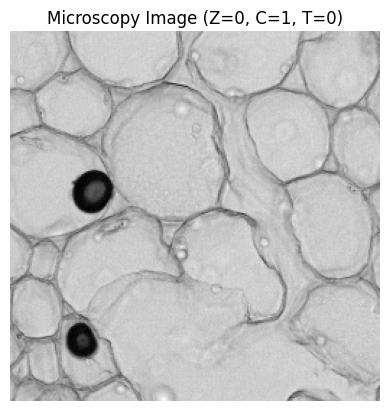

In [3]:
# Read the image
reader = bioformats.ImageReader(file_path)
image = reader.read(z=0, c=1, t=0, rescale=False)

# Display with matplotlib
plt.imshow(image, cmap='gray')
plt.title("Microscopy Image (Z=0, C=1, T=0)")
plt.axis('off')
plt.show()

In [ ]:
# Get metadata using the OME metadata store
metadata = bioformats.get_omexml_metadata(file_path)
ome = bioformats.OMEXML(metadata)

# Access the first image in the file
pixels = ome.image(0).Pixels

# Get pixel sizes and units
pixel_size_x = pixels.PhysicalSizeX
pixel_size_y = pixels.PhysicalSizeY
pixel_size_z = pixels.PhysicalSizeZ
unit_x = pixels.PhysicalSizeXUnit
unit_y = pixels.PhysicalSizeYUnit
unit_z = pixels.PhysicalSizeZUnit

print("Pixel size X:", pixel_size_x, unit_x)
print("Pixel size Y:", pixel_size_y, unit_y)
print("Pixel size Z:", pixel_size_z, unit_z)

Pixel size X: 0.621480569402239 µm
Pixel size Y: 0.621480569402239 µm
Pixel size Z: 3.0 µm
